In [1]:
# Libraries, modules
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
from scipy import signal

# Read audio recording
data, fs = sf.read('./signal_sequences/000_1.392_seq.flac')
l_ch = data[:,0] # Left channel
#r_ch = data[:,0] # Right channel

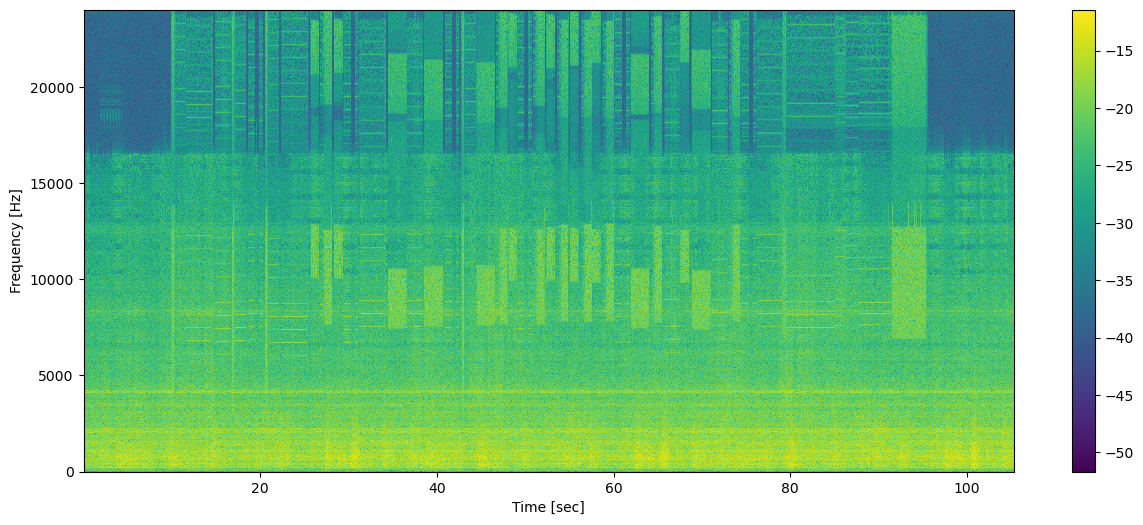

In [2]:
## Spectrogram (2D FFT) (only L channel for now)

# Generate spectrogram
win_size = 4096
f, t, spectrogram = signal.spectrogram(l_ch, fs, window='hann', nperseg=win_size, noverlap=win_size/2)

# Plot spectrogram (in dB)
plt.figure(figsize=(15,6))
plt.pcolormesh(t, f, np.log(spectrogram))
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

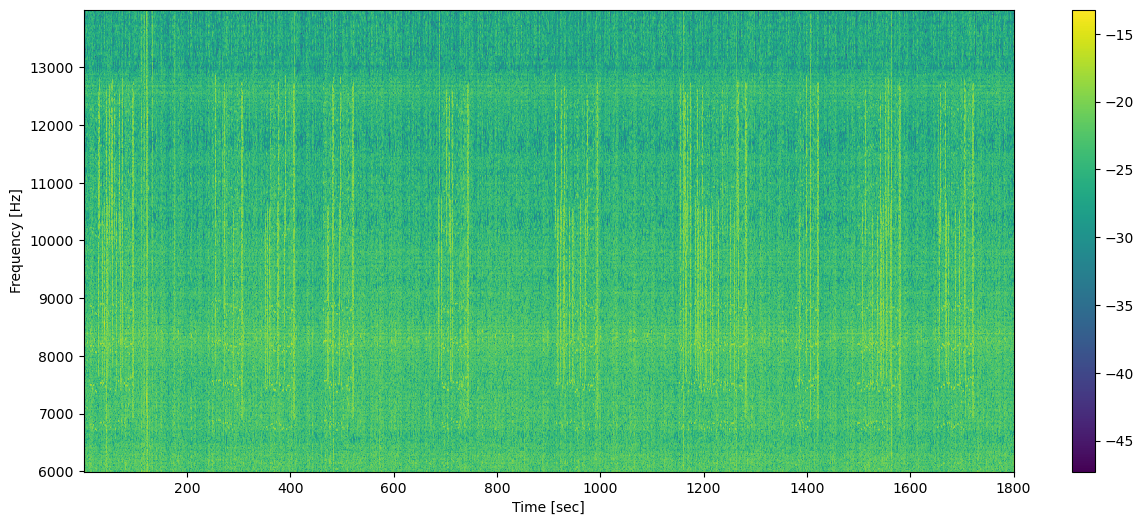

In [8]:
## Crop spectrogram for end signal search

# Time range
t_start = 0 # seconds
t_end = 1800 # seconds

# Frequency range
f_low = 6000 # Hz
f_high = 14000 # Hz

# Crop spectrogram
t_0 = int(t_start*len(t)/np.max(t))
t_1 = int(t_end*len(t)/np.max(t))
f_0 = int(f_low*len(f)/np.max(f))
f_1 = int(f_high*len(f)/np.max(f))
spec_crop = spectrogram[f_0:f_1,t_0:t_1]

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.pcolormesh(t[t_0:t_1], f[f_0:f_1], np.log(spec_crop))
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

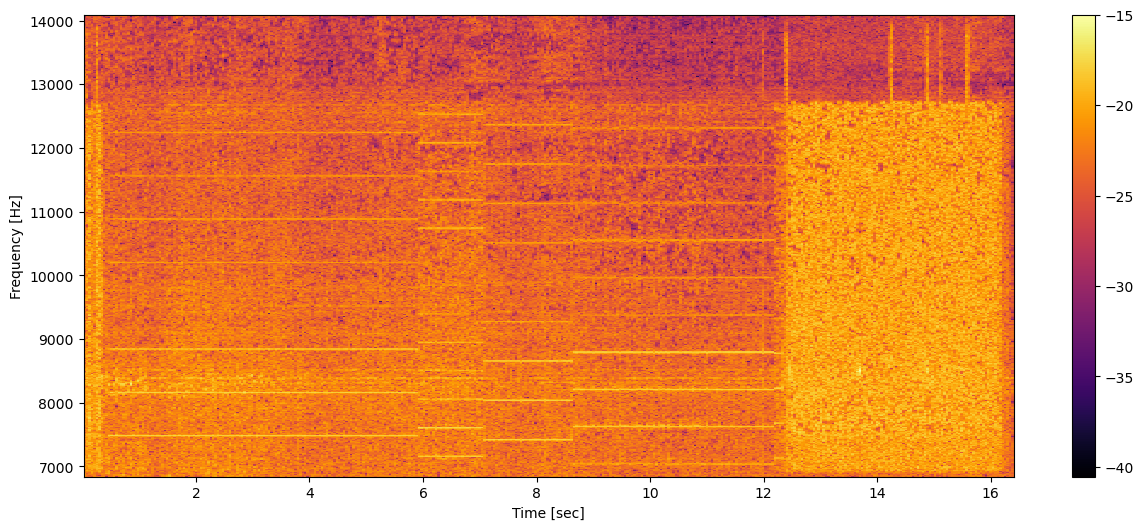

In [9]:
## Isolate end signal (full)

# Time range
time_start = 80.55 # seconds
time_end = 97.0 # seconds

# Extract time segment
time_0 = int(time_start*fs)
time_1 = int(time_end*fs)
segment = l_ch[time_0:time_1]

# Frequency range
f_l = 6850 # Hz
f_h = 14100 # Hz

# Generate spectrogram (2D FFT) of each audio channel (only L for now)
win_size = 4096
f, t, spectrogram = signal.spectrogram(segment, fs, window='hann', nperseg=win_size, noverlap=win_size/2)

# Cut frequencies
f_min = int(f_l*len(f)/np.max(f))
f_max = int(f_h*len(f)/np.max(f))
f_cut = f[f_min:f_max]
endsig_full = spectrogram[f_min:f_max,:]

# Plot spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(t, f_cut, np.log(endsig_full), cmap="inferno")
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

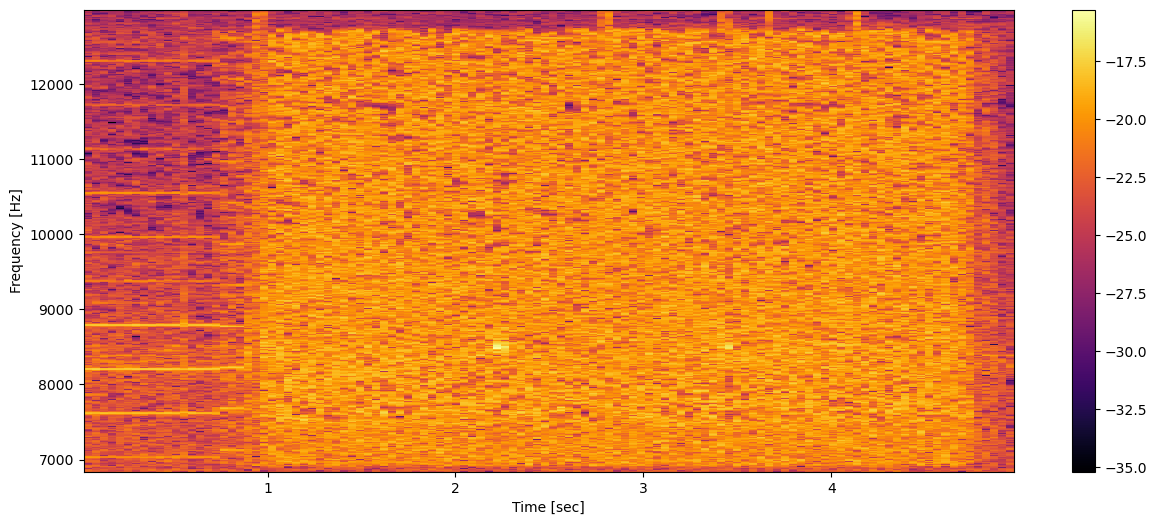

In [10]:
## Isolate end signal (only final block + some tones)

# Time range
time_start = 92 # seconds
time_end = 97.0 # seconds

# Extract time segment
time_0 = int(time_start*fs)
time_1 = int(time_end*fs)
segment = l_ch[time_0:time_1]

# Frequency range
f_l = 6850 # Hz
f_h = 13000 # Hz

# Generate spectrogram (2D FFT) of each audio channel (only L for now)
win_size = 4096
f, t, spectrogram = signal.spectrogram(segment, fs, window='hann', nperseg=win_size, noverlap=win_size/2)

# Cut frequencies
f_min = int(f_l*len(f)/np.max(f))
f_max = int(f_h*len(f)/np.max(f))
f_cut = f[f_min:f_max]
endsig_small = spectrogram[f_min:f_max,:]

# Plot spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(t, f_cut, np.log(endsig_small), cmap="inferno")
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

(525, 116)

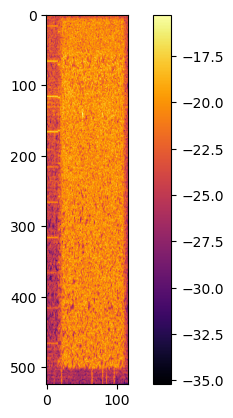

In [11]:
# Define end signal array (plot is flipped vertically)

end_signal = np.log(endsig_small).astype(np.float32)
plt.imshow(end_signal, cmap="inferno")
plt.colorbar()
end_signal.shape

(683, 42187)

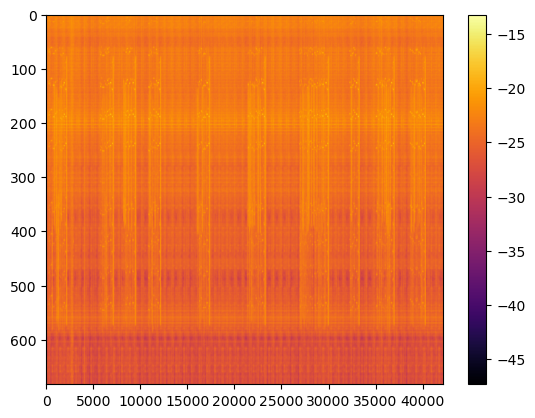

In [12]:
# Define recording array  (plot is flipped vertically)
 
recording = np.log(spec_crop).astype(np.float32)
plt.imshow(recording, aspect='auto', cmap="inferno")
plt.colorbar()
recording.shape

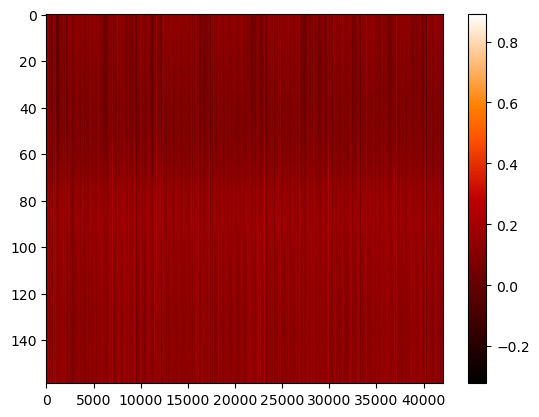

In [13]:
## Search based on OpenCV match template
# very fast

import cv2

correlation_opencv = cv2.matchTemplate(recording, end_signal, cv2.TM_CCOEFF_NORMED)

plt.imshow(correlation_opencv, aspect='auto', cmap="gist_heat")
plt.colorbar()

[[   72  2156]
 [   72 17354]
 [   72 33234]
 [   72 23243]
 [   72  7099]
 [   72 12138]
 [   72  9479]
 [   72 40268]
 [   72 36946]
 [   72 29976]]


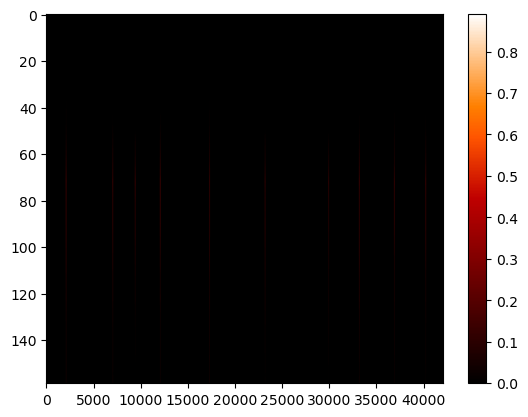

In [14]:
## Filter OpenCV correlation results and print local maxima locations

filtered_corr = np.copy(correlation_opencv)
filtered_corr[filtered_corr < 0.4] = 0
plt.imshow(filtered_corr, aspect='auto', cmap="gist_heat")
plt.colorbar()

from skimage.feature import peak_local_max
dist = correlation_opencv.shape[0]//4
xy = peak_local_max(correlation_opencv, min_distance=dist, threshold_abs=0.5)
print(xy)

In [ ]:
## Search based on median of absolute difference
# Similarity is lowest when matches occur, it should be very close to zero
# Slow, about the same as the audio duration
# It breaks for recordings longer than 5-10 min
# Better to use this for single sequences instead of full recordings

import time

start_time = time.time()

# Initialize the similarity matrix with the appropriate shape
similarity = np.zeros((recording.shape[0] - end_signal.shape[0] + 1, recording.shape[1] - end_signal.shape[1] + 1))

# Loop over each position in the similarity matrix (sliding windows)
for r in range(similarity.shape[0]):
    for c in range(similarity.shape[1]):        
        sliding_win = recording[r:r+end_signal.shape[0], c:c+end_signal.shape[1]] # Extract the current window from the recording
        similarity[r, c] = np.median(np.abs(end_signal - sliding_win)) # Calculate median of absolute difference between window and signal

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(similarity, cmap="inferno")
plt.colorbar()